# Notebook 04 — Hand Data Prep
### Build hand-landmark numpy arrays from CSVs and perform stratified split

---

## Cell 1 — Imports & Constants



In [10]:
import pathlib
import json
import pickle
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# ── Constants ────────────────────────────────────────────────
RANDOM_SEED  = 42
SEQUENCE_LEN = 60
NUM_FEATURES = 126
TRAIN_SIZE   = 0.70
VAL_SIZE     = 0.10   # of total — SSL400 suggested split
TEST_SIZE    = 0.20   # of total

CSV_ROOT   = pathlib.Path("../data/archive/Dataset - Hand - CSV")
VIDEO_ROOT = pathlib.Path("../data/archive/Dataset - Original")
OUT_DIR    = pathlib.Path("../data/hand_v3")
MODEL_DIR  = pathlib.Path("../saved_models/v3")

OUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("Constants loaded.")
print(f"CSV source  : {CSV_ROOT}")
print(f"Output dir  : {OUT_DIR}")


Constants loaded.
CSV source  : ../data/archive/Dataset - Hand - CSV
Output dir  : ../data/hand_v3




---

## Cell 2 — Verify Extraction Output



In [11]:
# Count all CSVs produced by extract_hand_landmarks.py
all_csvs = sorted(CSV_ROOT.rglob("*.csv"))
print(f"Total CSVs found: {len(all_csvs)}")

# Spot-check 5 random CSVs for correct shape
sample_csvs = random.sample(all_csvs, min(5, len(all_csvs)))
print("\nSpot-check (should all be shape (60, 126)):")

shape_errors = []
for p in sample_csvs:
    df = pd.read_csv(p, header=None)
    shape = df.shape
    ok = (shape == (SEQUENCE_LEN, NUM_FEATURES))
    print(f"  {'✓' if ok else '✗'} {p.parent.name}/{p.name} → {shape}")
    if not ok:
        shape_errors.append(p)

if shape_errors:
    print(f"\nWARNING: {len(shape_errors)} CSVs have wrong shape.")
else:
    print("\nAll spot-check CSVs have correct shape.")


Total CSVs found: 4236

Spot-check (should all be shape (60, 126)):
  ✓ Time/Time_018.csv → (60, 126)
  ✓ Good/Good_051.csv → (60, 126)
  ✓ Telephone/Telephone_003.csv → (60, 126)
  ✓ Pencil/Pencil_008.csv → (60, 126)
  ✓ Laptop/Laptop_010.csv → (60, 126)

All spot-check CSVs have correct shape.




---

## Cell 3 — Cross-Check CSVs vs Original Videos



In [12]:
all_videos = sorted(p for p in VIDEO_ROOT.rglob("*") if p.suffix.lower() in {".mp4", ".mov"})
print(f"Total videos: {len(all_videos)}")

# Build sets of stems for comparison
video_stems = {v.relative_to(VIDEO_ROOT).with_suffix("") for v in all_videos}
csv_stems   = {c.relative_to(CSV_ROOT).with_suffix("")   for c in all_csvs}

missing_csvs  = video_stems - csv_stems   # videos without a CSV
orphan_csvs   = csv_stems - video_stems   # CSVs without a video

print(f"\nVideos without a CSV : {len(missing_csvs)}")
print(f"CSVs without a video : {len(orphan_csvs)}")

if missing_csvs:
    print("\nMissing CSVs (first 10):")
    for s in sorted(missing_csvs)[:10]:
        print(f"  {s}")


Total videos: 4236

Videos without a CSV : 0
CSVs without a video : 0




---

## Cell 4 — Load All Sequences



In [13]:
X_list = []
y_list = []
skipped = []

for csv_path in sorted(CSV_ROOT.rglob("*.csv")):
    try:
        df = pd.read_csv(csv_path, header=None)
        if df.shape != (SEQUENCE_LEN, NUM_FEATURES):
            skipped.append((str(csv_path), f"wrong shape {df.shape}"))
            continue

        arr = df.values.astype(np.float32)  # (60, 126)
        sign_name = csv_path.parent.name     # directory name = sign label
        X_list.append(arr)
        y_list.append(sign_name)

    except Exception as e:
        skipped.append((str(csv_path), str(e)))

X = np.array(X_list, dtype=np.float32)   # (N, 60, 126)
y = np.array(y_list)                      # (N,) string labels

print(f"Total loaded  : {len(X)}")
print(f"Total skipped : {len(skipped)}")
print(f"Unique classes: {len(np.unique(y))}")
print(f"X shape       : {X.shape}")

if skipped:
    print("\nSkipped files (first 10):")
    for path, reason in skipped[:10]:
        print(f"  {reason} — {path}")


Total loaded  : 4236
Total skipped : 0
Unique classes: 383
X shape       : (4236, 60, 126)




---

## Cell 5 — Class Distribution Check



Min samples/class    : 1
Max samples/class    : 116
Mean samples/class   : 11.1
Median samples/class : 7.0
Classes with < 2     : 30
Classes with < 5     : 139


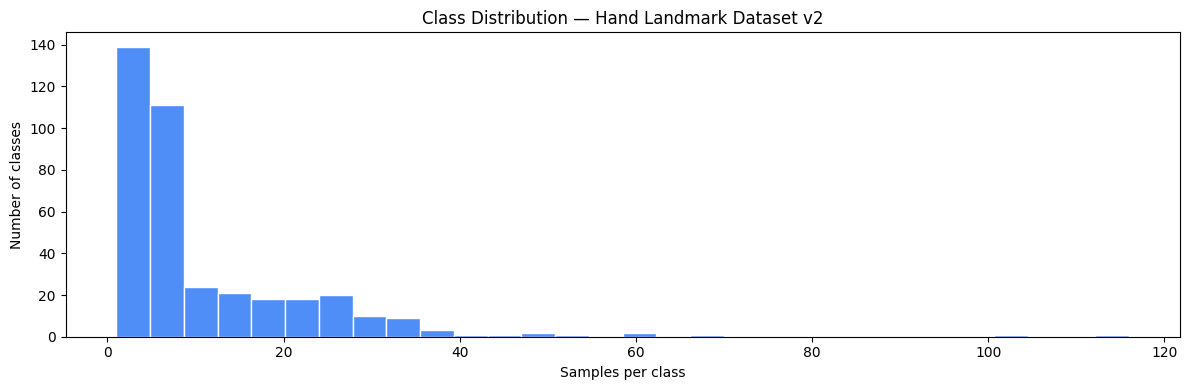

Saved: ../saved_models/v3/class_distribution_v2.png


In [14]:
from collections import Counter

class_counts = Counter(y)
counts = np.array(list(class_counts.values()))

print(f"Min samples/class    : {counts.min()}")
print(f"Max samples/class    : {counts.max()}")
print(f"Mean samples/class   : {counts.mean():.1f}")
print(f"Median samples/class : {np.median(counts):.1f}")
print(f"Classes with < 2     : {(counts < 2).sum()}")
print(f"Classes with < 5     : {(counts < 5).sum()}")

# Plot histogram
fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(counts, bins=30, color="#4f8ef7", edgecolor="white")
ax.set_xlabel("Samples per class")
ax.set_ylabel("Number of classes")
ax.set_title("Class Distribution — Hand Landmark Dataset v2")
plt.tight_layout()
plt.savefig(MODEL_DIR / "class_distribution_v2.png", dpi=150)
plt.show()
print(f"Saved: {MODEL_DIR / 'class_distribution_v2.png'}")




---

## Cell 6 — Stratified Train / Val / Test Split



In [15]:
MIN_SAMPLES_PER_CLASS = 3  # below this, a class can't get real val+test coverage

class_counts = Counter(y)
excluded_classes = {c for c, n in class_counts.items() if n < MIN_SAMPLES_PER_CLASS}
if excluded_classes:
    print(f"WARNING: {len(excluded_classes)} classes have < {MIN_SAMPLES_PER_CLASS} samples "
          f"and will be EXCLUDED from the trainable set:")
    for c in sorted(excluded_classes):
        print(f"  {c}: {class_counts[c]} sample(s)")

eligible_mask = np.array([label not in excluded_classes for label in y])
X_elig, y_elig = X[eligible_mask], y[eligible_mask]

X_train, X_temp, y_train, y_temp = train_test_split(
    X_elig, y_elig,
    test_size=(VAL_SIZE + TEST_SIZE),
    random_state=RANDOM_SEED,
    stratify=y_elig,
)

temp_counts = Counter(y_temp)
temp_single_mask = np.array([temp_counts[label] == 1 for label in y_temp])
X_temp_single, y_temp_single = X_temp[temp_single_mask], y_temp[temp_single_mask]
X_temp_multi, y_temp_multi = X_temp[~temp_single_mask], y_temp[~temp_single_mask]

if temp_single_mask.sum():
    print(f"\nTemp single-sample items (forced to train): {temp_single_mask.sum()}")

val_relative = VAL_SIZE / (VAL_SIZE + TEST_SIZE)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp_multi, y_temp_multi,
    test_size=(1 - val_relative),
    random_state=RANDOM_SEED,
    stratify=y_temp_multi,
)

X_train = np.concatenate([X_train, X_temp_single], axis=0)
y_train = np.concatenate([y_train, y_temp_single], axis=0)

print(f"\nSplit sizes:")
print(f"  Train : {len(X_train):5d} ({len(X_train)/len(X_elig)*100:.1f}%)")
print(f"  Val   : {len(X_val):5d} ({len(X_val)/len(X_elig)*100:.1f}%)")
print(f"  Test  : {len(X_test):5d} ({len(X_test)/len(X_elig)*100:.1f}%)")

train_classes, val_classes, test_classes = set(y_train), set(y_val), set(y_test)
train_only = train_classes - val_classes - test_classes
print(f"\nClasses excluded (< {MIN_SAMPLES_PER_CLASS} samples): {len(excluded_classes)}")
print(f"Classes train-only (post-threshold rounding orphans): {len(train_only)}")
assert train_classes >= val_classes, "Val has classes not in train!"
assert train_classes >= test_classes, "Test has classes not in train!"

with open(MODEL_DIR / "excluded_classes_v2.json", "w") as f:
    json.dump(sorted(excluded_classes), f, indent=2)
print(f"Saved: {MODEL_DIR / 'excluded_classes_v2.json'}")


  12. twelve: 2 sample(s)
  17. seventeen: 2 sample(s)
  20. twenty: 2 sample(s)
  Airport: 2 sample(s)
  Bank: 2 sample(s)
  Bathe: 2 sample(s)
  Boil: 2 sample(s)
  Break: 2 sample(s)
  Bring: 2 sample(s)
  Brother in law: 1 sample(s)
  Bus station: 2 sample(s)
  Buy: 2 sample(s)
  Careful: 1 sample(s)
  Carry: 2 sample(s)
  Chain: 1 sample(s)
  Church: 2 sample(s)
  Clearly: 1 sample(s)
  Color: 1 sample(s)
  Cow: 1 sample(s)
  Day after tomorrow: 1 sample(s)
  Difficult: 2 sample(s)
  Dont: 1 sample(s)
  Dont know: 2 sample(s)
  Draw: 2 sample(s)
  Evening: 2 sample(s)
  Families: 1 sample(s)
  Flower: 1 sample(s)
  Get up: 2 sample(s)
  Gray: 1 sample(s)
  Hospital: 2 sample(s)
  How are you: 2 sample(s)
  How many: 1 sample(s)
  How much: 2 sample(s)
  I know: 2 sample(s)
  Jump: 2 sample(s)
  Make: 2 sample(s)
  Milk: 1 sample(s)
  Moon: 1 sample(s)
  Morning: 2 sample(s)
  Next door: 1 sample(s)
  Not like (dislike): 2 sample(s)
  Now: 2 sample(s)
  Police: 1 sample(s)
  Quickl



---

## Cell 7 — Label Encoding (Fit on Train Only)



In [16]:
le = LabelEncoder()
le.fit(y_train)

NUM_CLASSES = len(le.classes_)
print(f"Number of classes: {NUM_CLASSES}")

# Check for out-of-vocabulary labels in val/test
oov_val  = set(y_val)  - set(le.classes_)
oov_test = set(y_test) - set(le.classes_)
if oov_val:
    print(f"WARNING: {len(oov_val)} OOV labels in val: {oov_val}")
if oov_test:
    print(f"WARNING: {len(oov_test)} OOV labels in test: {oov_test}")

# Encode
y_train_enc = le.transform(y_train)
y_val_enc   = le.transform(y_val)
y_test_enc  = le.transform(y_test)

# One-hot encode
def to_onehot(y_int, num_classes):
    out = np.zeros((len(y_int), num_classes), dtype=np.float32)
    out[np.arange(len(y_int)), y_int] = 1.0
    return out

y_train_oh = to_onehot(y_train_enc, NUM_CLASSES)
y_val_oh   = to_onehot(y_val_enc,   NUM_CLASSES)
y_test_oh  = to_onehot(y_test_enc,  NUM_CLASSES)

print(f"\ny_train_oh shape: {y_train_oh.shape}")
print(f"y_val_oh   shape: {y_val_oh.shape}")
print(f"y_test_oh  shape: {y_test_oh.shape}")

# Save encoder
with open(MODEL_DIR / "label_encoder_v2.pkl", "wb") as f:
    pickle.dump(le, f)
print(f"Saved: {MODEL_DIR / 'label_encoder_v2.pkl'}")

# Save label map (index → sign name)
label_map = {int(i): name for i, name in enumerate(le.classes_)}
with open(MODEL_DIR / "label_map_v2.json", "w") as f:
    json.dump(label_map, f, indent=2)
print(f"Saved: {MODEL_DIR / 'label_map_v2.json'}")


Number of classes: 312

y_train_oh shape: (2958, 312)
y_val_oh   shape: (388, 312)
y_test_oh  shape: (778, 312)
Saved: ../saved_models/v3/label_encoder_v2.pkl
Saved: ../saved_models/v3/label_map_v2.json




---

## Cell 8 — Save All Arrays



In [17]:
files_to_save = {
    "X_train_hand.npy": X_train,
    "X_val_hand.npy"  : X_val,
    "X_test_hand.npy" : X_test,
    "y_train_hand.npy": y_train_oh,
    "y_val_hand.npy"  : y_val_oh,
    "y_test_hand.npy" : y_test_oh,
}

print("Saving arrays to:", OUT_DIR)
print(f"{'File':<25} {'Shape':<25} {'Size (MB)'}")
print("-" * 60)

for filename, arr in files_to_save.items():
    path = OUT_DIR / filename
    np.save(path, arr)
    size_mb = path.stat().st_size / 1e6
    print(f"{filename:<25} {str(arr.shape):<25} {size_mb:.1f} MB")

print("\nAll arrays saved successfully.")


Saving arrays to: ../data/hand_v3
File                      Shape                     Size (MB)
------------------------------------------------------------
X_train_hand.npy          (2958, 60, 126)           89.5 MB
X_val_hand.npy            (388, 60, 126)            11.7 MB
X_test_hand.npy           (778, 60, 126)            23.5 MB
y_train_hand.npy          (2958, 312)               3.7 MB
y_val_hand.npy            (388, 312)                0.5 MB
y_test_hand.npy           (778, 312)                1.0 MB

All arrays saved successfully.




---

## Cell 9 — Findings Summary



In [18]:
print("=" * 50)
print("FINDINGS SUMMARY")
print("=" * 50)
print(f"Total CSVs loaded  : {len(X)}")
print(f"Total skipped      : {len(skipped)}")
print(f"Unique classes     : {NUM_CLASSES}")
print(f"Train / Val / Test : {len(X_train)} / {len(X_val)} / {len(X_test)}")
print(f"Classes train-only : {len(train_only)}")
print(f"OOV val warnings   : {'yes' if oov_val else 'no'}")
print(f"OOV test warnings  : {'yes' if oov_test else 'no'}")
print("=" * 50)


FINDINGS SUMMARY
Total CSVs loaded  : 4236
Total skipped      : 0
Unique classes     : 312
Train / Val / Test : 2958 / 388 / 778
Classes train-only : 72
OOV val warnings   : no
OOV test warnings  : no




---

> **Note on normalisation:** No MinMaxScaler is applied here. The wrist-relative,
> palm-scale normalisation was applied during extraction in `extract_hand_landmarks.py`.
> Applying a second global scaler would distort the geometric meaning of coordinates.
> The BiGRU handles the resulting value range (typically −3 to +3) natively.
